# これはなに
- lightgbm・xgboost・catboost・random forestの汎用パイプライン
- ハイパラチューニング含めて同じコードで4つとも動く
- 参照：https://www.kaggle.com/code/horsek/fb-eff-157a-stage3-train

In [ ]:
# 再現性のためのseedとfold数指定
class CFG:
    seed = 42
    n_fold = 3

In [ ]:
# colabでは足りないパッケージをインストール
!pip install catboost
!pip install optuna

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 76.6 MB 76.3 MB/s 
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 348 kB 15.6 MB/s 
     |████████████████████████████████| 81 kB 9.9 MB/s 
     |████████████████████████████████| 209 kB 57.3 MB/s 
     |████████████████████████████████| 78 kB 7.7 MB/s 
     |████████████████████████████████| 50 kB 6.7 MB/s 
     |████████████████████████████████| 147 kB 55.7 MB/s 
     |████████████████████████████████| 112 kB 56.7 MB/s 
  Created wheel for pyperclip: filename=pyperclip-1.8.2-py3-none-any.whl size=11137 sha256=c5085a25351d50b4cab3fc455692495e58503849dda7523f8e0b66af40c2821b
  Stored in directory: /root/.cache/pip/wheels/9f/18/84/8f69f8b08169c7bae2dde6bd7daf0c19fca8c8e500ee620a28
Successfully built pyperclip


In [ ]:
import os
import gc
import re
import ast
import sys
import copy
import json
import time
import math
import shutil
import string
import pickle
import random
import joblib
import itertools
from joblib import Parallel, delayed
from pathlib import Path
import warnings
import torch
warnings.filterwarnings("ignore")

import scipy as sp
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, GroupKFold, KFold

In [ ]:
# 事前にディレクトリの移動
%cd '/content/drive/Shareddrives/All staff/12_アルバイト・インターン/メンバーズ/わんわん/コード類/汎用コード'

/content/drive/Shareddrives/All staff/12_アルバイト・インターン/メンバーズ/わんわん/コード類/汎用コード


In [ ]:
# seed固定
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(seed=CFG.seed)

# =======各種cv=======
# foldのデータフレームが返ってくる
def get_kfold(train, n_splits, seed):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    generator = kf.split(train)
    fold_series = []
    for fold, (idx_train, idx_valid) in enumerate(generator):
        fold_series.append(pd.Series(fold, index=idx_valid))
    fold_series = pd.concat(fold_series).sort_index()
    return fold_series

def get_stratifiedkfold(train, target_col, n_splits, seed):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    generator = kf.split(train, train[target_col])
    fold_series = []
    for fold, (idx_train, idx_valid) in enumerate(generator):
        fold_series.append(pd.Series(fold, index=idx_valid))
    fold_series = pd.concat(fold_series).sort_index()
    return fold_series

def get_groupkfold(train, target_col, group_col, n_splits):
    kf = GroupKFold(n_splits=n_splits)
    generator = kf.split(train, train[target_col], train[group_col])
    fold_series = []
    for fold, (idx_train, idx_valid) in enumerate(generator):
        fold_series.append(pd.Series(fold, index=idx_valid))
    fold_series = pd.concat(fold_series).sort_index()
    return fold_series

def get_groupstratifiedkfold(train, target_col, group_col, n_splits, seed):
    kf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    generator = kf.split(train, train[target_col], train[group_col])
    fold_series = []
    for fold, (idx_train, idx_valid) in enumerate(generator):
        fold_series.append(pd.Series(fold, index=idx_valid))
    fold_series = pd.concat(fold_series).sort_index()
    return fold_series

In [ ]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# 前処理は簡易的に済ませる
# いらないカラム削除
drop = ['Name', 'PassengerId', 'Ticket', 'Cabin']
train.drop(drop, axis=1, inplace=True)
test.drop(drop, axis=1, inplace=True)

# one-hot
onehot = ['Sex', 'Embarked']
train = pd.get_dummies(train, columns = onehot, drop_first=True)
test = pd.get_dummies(test, columns = onehot, drop_first=True)

# 平均値で欠損値補完
train = train.fillna(train.mean())
test = test.fillna(test.mean())

In [ ]:
train.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [ ]:
# fold追加
fold = get_stratifiedkfold(train, 'Survived', CFG.n_fold, CFG.seed)
train['fold'] = fold

In [ ]:
train

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,fold
0,0,3,22.000000,1,0,7.2500,1,0,1,1
1,1,1,38.000000,1,0,71.2833,0,0,0,2
2,1,3,26.000000,0,0,7.9250,0,0,1,2
3,1,1,35.000000,1,0,53.1000,0,0,1,2
4,0,3,35.000000,0,0,8.0500,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,0,1,1
887,1,1,19.000000,0,0,30.0000,0,0,1,1
888,0,3,29.699118,1,2,23.4500,0,0,1,2
889,1,1,26.000000,0,0,30.0000,1,0,0,1


In [ ]:
# ====================================================
# Model
# ====================================================
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.utils.extmath import softmax
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.ensemble import RandomForestClassifier as rfc
from sklearn.ensemble import RandomForestRegressor as rfr

import optuna
optuna.logging.disable_default_handler()


class TabularModel:
    def __init__(
        self,
        model,
        param,
        n_fold,
        train_df,
        num_features,
        cat_features,
        target_col,
        num_class=1,
        output_dir='./',
        objective='regression',
    ):
        super().__init__()
        assert objective in ["regression", "classification"], 'SELECT model from ["regression", "classification"]'

        """
        引数
        model : 'LGB'か'XGB'か'CAT', または'RF'を選ぶ
        param : モデルのパラメータ
        n_fold : foldの数
        train_df : trainデータ
        num_features : 数値の特徴量
        cat_features : カテゴリの特徴量
        target_col : targetのカラム名
        num_class : 分類時のクラス数（回帰は1）
        output_dir : モデルの保存先
        objectibe : 回帰なのか分類なのかを指定
        """

        self.model = model
        self.param = param
        self.n_fold = n_fold
        self.num_round = 100000
        self.verbose_eval = 100
        self.early_stopping_rounds = 100
        self.num_class = num_class
        if num_class == 1:
            self.oof = np.zeros(len(train_df))
        elif num_class > 1:
            self.oof = np.zeros((len(train_df), num_class))
        self.num_features = num_features
        self.cat_features = cat_features
        self.features = num_features + cat_features
        self.target = train_df[target_col]
        self.objective = objective
        self.output_dir = output_dir

    def create_labels(self, y_true):
        """Helper function for scoring"""
        labels = []
        for key in y_true:
            label = np.zeros(2)
            label[key] = 1
            labels.append(label)
        labels = np.vstack(labels)
        return labels

    # モデルのスコアを確認する（ここはタスクによって確認）
    def get_score(self, y_true, y_pred):
        """Define scoring function"""
        labels = self.create_labels(y_true)
        score = log_loss(labels, y_pred)
        return score

    # lightgbmの学習
    def _lgb_train(self, param, train_df, trn_idx, val_idx):
        feature_importance_df = pd.DataFrame()
        feature_importance_df["feature"] = self.features
        if self.cat_features == []:
            trn_data = lgb.Dataset(train_df.iloc[trn_idx][self.features], label=self.target.iloc[trn_idx].values)
            val_data = lgb.Dataset(train_df.iloc[val_idx][self.features], label=self.target.iloc[val_idx].values)
        else:
            trn_data = lgb.Dataset(train_df.iloc[trn_idx][self.features], label=self.target.iloc[trn_idx].values,
                                   categorical_feature=self.cat_features)
            val_data = lgb.Dataset(train_df.iloc[val_idx][self.features], label=self.target.iloc[val_idx].values,
                                   categorical_feature=self.cat_features)
        clf = lgb.train(param,
                        trn_data,
                        self.num_round,
                        valid_sets=[trn_data, val_data],
                        verbose_eval=self.verbose_eval,
                        early_stopping_rounds=self.early_stopping_rounds)
        self.oof[val_idx] = clf.predict(train_df.iloc[val_idx][self.features], num_iteration=clf.best_iteration)
        feature_importance_df["importance"] = clf.feature_importance(importance_type='gain')
        return clf, feature_importance_df

    # xgboostの前処理、学習
    def _xgb_preprocess(self, df):
        df = df.replace(np.inf, np.nan)
        df = df.replace(-np.inf, np.nan)
        return df

    def _xgb_train(self, param, train_df, trn_idx, val_idx):
        feature_importance_df = pd.DataFrame()
        feature_importance_df["feature"] = self.features
        train_df = self._xgb_preprocess(train_df)
        d_train = xgb.DMatrix(data=train_df.iloc[trn_idx][self.features], label=self.target.iloc[trn_idx].values)
        d_valid = xgb.DMatrix(data=train_df.iloc[val_idx][self.features], label=self.target.iloc[val_idx].values)
        watchlist = [(d_train, 'train'), (d_valid, 'valid')]
        clf = xgb.train(dtrain=d_train,
                        num_boost_round=self.num_round,
                        evals=watchlist,
                        early_stopping_rounds=self.early_stopping_rounds,
                        verbose_eval=self.verbose_eval,
                        params=param)
        self.oof[val_idx] = clf.predict(xgb.DMatrix(train_df.iloc[val_idx][self.features]), ntree_limit=clf.best_ntree_limit)
        feature_importance_df["importance"] = feature_importance_df["feature"].map(clf.get_score(importance_type='gain'))
        return clf, feature_importance_df

    # catboostの前処理、学習
    def _column_index(self, df, query_cols):
        cols = df.columns.values
        sidx = np.argsort(cols)
        return sidx[np.searchsorted(cols, query_cols, sorter=sidx)]

    def _cat_train(self, param, train_df, trn_idx, val_idx):
        feature_importance_df = pd.DataFrame()
        feature_importance_df["feature"] = self.features
        X_tr, y_tr = train_df.iloc[trn_idx][self.features], self.target.iloc[trn_idx].values
        X_val, y_val = train_df.iloc[val_idx][self.features], self.target.iloc[val_idx].values
        categorical_features_pos = self._column_index(X_tr, self.cat_features)
        if self.objective == 'regression':
            clf = cb.CatBoostRegressor(**param)
            clf.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                    cat_features=categorical_features_pos,
                    use_best_model=True)
            self.oof[val_idx] = clf.predict(X_val)
        elif self.objective == 'classification':
            clf = cb.CatBoostClassifier(**param)
            clf.fit(X_tr, y_tr, eval_set=(X_val, y_val),
                    cat_features=categorical_features_pos,
                    use_best_model=True)
            self.oof[val_idx] = clf.predict_proba(X_val)
        feature_importance_df["importance"] = clf.feature_importances_
        return clf, feature_importance_df

    # random forestの学習
    def _rf_train(self, param, train_df, trn_idx, val_idx):
        feature_importance_df = pd.DataFrame()
        feature_importance_df["feature"] = self.features
        X_tr, y_tr = train_df.iloc[trn_idx][self.features], self.target.iloc[trn_idx].values
        X_val, y_val = train_df.iloc[val_idx][self.features], self.target.iloc[val_idx].values
        if self.objective == 'regression':
            clf = rfr(**param)
            clf.fit(X_tr, y_tr)
            self.oof[val_idx] = clf.predict(X_val)
        elif self.objective == 'classification':
            clf = rfc(**param)
            clf.fit(X_tr, y_tr)
            self.oof[val_idx] = clf.predict_proba(X_val)
        feature_importance_df["importance"] = clf.feature_importances_
        return clf, feature_importance_df

    # foldごとの学習ループ
    def train(self, param, train_df):
        self.val_idxes = []
        self.model_paths = []
        self.feature_importance_df = pd.DataFrame()
        for fold in range(self.n_fold):
            print(f"===== Fold {fold} =====")
            trn_idx = train_df[train_df['fold'] != fold].index
            val_idx = train_df[train_df['fold'] == fold].index
            print(f'train: {len(trn_idx)} valid: {len(val_idx)}')
            if self.model == "LGB":
                clf, fold_importance_df = self._lgb_train(param, train_df, trn_idx, val_idx)
            elif self.model == "XGB":
                clf, fold_importance_df = self._xgb_train(param, train_df, trn_idx, val_idx)
            elif self.model == "CAT":
                clf, fold_importance_df = self._cat_train(param, train_df, trn_idx, val_idx)
            elif self.model == "RF":
                clf, fold_importance_df = self._rf_train(param, train_df, trn_idx, val_idx)
            else:
                raise NotImplementedError("Only TREE models supported.")
            # 以下の4行はモデルを保存しておくときに使う。
            # model_path = self.output_dir + f'{self.model}_fold{fold}.pkl'
            # self.model_paths.append(model_path)
            # with open(model_path, 'wb') as fout:
            #     pickle.dump(clf, fout)
            if fold_importance_df is not None:
                fold_importance_df['fold'] = fold
                self.feature_importance_df = pd.concat([self.feature_importance_df, fold_importance_df], axis=0)
            self.val_idxes.append(val_idx)
            score = self.get_score(self.target.iloc[val_idx].values, self.oof[val_idx])
            print(f"Fold{fold} score: {score:.6f}")
        self.val_idxes = np.concatenate(self.val_idxes)
        score = self.get_score(self.target.iloc[self.val_idxes].values, self.oof[self.val_idxes])
        print(f"CV score: {score:.6f}")


    # パラメータの最適化
    def optimize_param(self, train_df, n_trials=10):
        base_param = self.param
        print('[start] param optimization')
        def objective(trial):
            param = base_param.copy()
            if self.model == "LGB":
                study_param = {
                    'subsample': trial.suggest_loguniform('subsample', 0.8, 1.0),
                    'subsample_freq': trial.suggest_int('subsample_freq', 1, 4),
                    'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-6, 1.0),
                    'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-6, 1.0),
                    'min_split_gain': trial.suggest_loguniform('min_split_gain', 1e-6, 1.0),
                }
            elif self.model == "XGB":
                study_param = {
                    'subsample': trial.suggest_loguniform('subsample', 0.8, 1.0),
                    'alpha': trial.suggest_loguniform('alpha', 1e-6, 1.0),
                    'lambda': trial.suggest_loguniform('lambda', 1e-6, 1.0),
                    'gamma': trial.suggest_loguniform('gamma', 1e-6, 1.0),
                }
            elif self.model == "CAT":
                study_param = {
                    'subsample': trial.suggest_loguniform('subsample', 0.8, 1.0),
                    'bagging_temperature': trial.suggest_loguniform('bagging_temperature', 1e-6, 1.0),
                    'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 4),
                }
            elif self.model == 'RF':
                study_param = {
                    'max_leaf_nodes':trial.suggest_int('max_leaf_nodes', 1,1000),
                    'n_estimators': trial.suggest_int('n_estimators', 1, 1000),
                    'min_samples_split':trial.suggest_int('min_samples_split',2,5),
                    'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,10),
                }

            else:
                raise NotImplementedError("Only GBDT models supported.")
            print(f"study_param: {study_param}")
            param.update(study_param)
            self.train(param, train_df)
            score = self.get_score(self.target[self.val_idxes].values, self.oof[self.val_idxes])
            return score
        study = optuna.create_study(sampler=optuna.samplers.RandomSampler(seed=42))
        study.optimize(objective, n_trials=n_trials)
        trial = study.best_trial
        best_params = trial.params.items()
        best_param_dict = dict(list(best_params))
        param = base_param.copy()
        param.update(best_param_dict)
        self.param = param
        print('[end] param optimization')

    def _lgb_predict(self, clf, test_df):
        prediction = clf.predict(test_df[self.features], num_iteration=clf.best_iteration)
        return prediction

    def _xgb_predict(self, clf, test_df):
        test_df = self._xgb_preprocess(test_df)
        prediction = clf.predict(xgb.DMatrix(test_df[self.features]), ntree_limit=clf.best_ntree_limit)
        return prediction

    def _cat_predict(self, clf, test_df):
        if self.objective == 'regression':
            prediction = clf.predict(test_df[self.features])
        elif self.objective == 'classification':
            prediction = clf.predict_proba(test_df[self.features])
        return prediction

    def _rf_predict(self, clf, test_df):
        if self.objective == 'regression':
            prediction = clf.predict(test_df[self.features])
        elif self.objective == 'classification':
            prediction = clf.predict_proba(test_df[self.features])
        return prediction

    # 各モデルの予測
    def predict(self, test_df):
        # 回帰用のpred
        if self.num_class == 1:
            predictions = np.zeros(len(test_df))
        # 分類用のpred
        elif self.num_class > 1:
            predictions = np.zeros((len(test_df), self.num_class))
        # モデル読み込み
        for model_path in self.model_paths:
            with open(model_path, 'rb') as fin:
                clf = pickle.load(fin)
            if self.model == 'LGB':
                prediction = self._lgb_predict(clf, test_df)
            elif self.model == 'XGB':
                prediction = self._xgb_predict(clf, test_df)
            elif self.model == 'CAT':
                prediction = self._cat_predict(clf, test_df)
            elif self.model == 'RF':
                prediction = self._cat_predict(clf, test_df)
            else:
                raise NotImplementedError("Only TREE models supported.")
            # foldごとのアンサンブル
            predictions += prediction / len(self.model_paths)
        return predictions

    # 特徴量重要度の可視化
    def show_feature_importance(self, figsize=(8, 16)):
        best_features = (self.feature_importance_df[["feature", "importance"]]
                         .groupby("feature", as_index=False).mean().sort_values(by="importance", ascending=False).head(50))
        plt.figure(figsize=figsize)
        sns.barplot(x="importance", y="feature", data=best_features)
        plt.title('Features importance (averaged/folds)')
        plt.tight_layout()

In [ ]:
# random forestを動かしてみる
param = {
    "criterion":"entropy",
    'max_depth': 3,
    'random_state': CFG.seed,
}

num_features = ['Age', 'Fare']
cat_features = ['Pclass', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S']

[start] param optimization
INFO:__main__:[start] param optimization
study_param: {'max_leaf_nodes': 375, 'n_estimators': 951, 'min_samples_split': 4, 'min_samples_leaf': 6}
INFO:__main__:study_param: {'max_leaf_nodes': 375, 'n_estimators': 951, 'min_samples_split': 4, 'min_samples_leaf': 6}
===== Fold 0 =====
INFO:__main__:===== Fold 0 =====
train: 594 valid: 297
INFO:__main__:train: 594 valid: 297
Fold0 score: 0.472174
INFO:__main__:Fold0 score: 0.472174
===== Fold 1 =====
INFO:__main__:===== Fold 1 =====
train: 594 valid: 297
INFO:__main__:train: 594 valid: 297
Fold1 score: 0.483026
INFO:__main__:Fold1 score: 0.483026
===== Fold 2 =====
INFO:__main__:===== Fold 2 =====
train: 594 valid: 297
INFO:__main__:train: 594 valid: 297
Fold2 score: 0.472692
INFO:__main__:Fold2 score: 0.472692
CV score: 0.475964
INFO:__main__:CV score: 0.475964
study_param: {'max_leaf_nodes': 157, 'n_estimators': 156, 'min_samples_split': 2, 'min_samples_leaf': 9}
INFO:__main__:study_param: {'max_leaf_nodes': 1

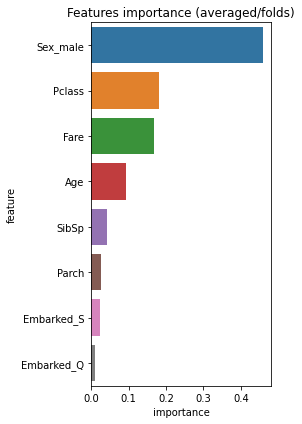

In [ ]:
model = TabularModel(model="RF",
                     param=param,
                     n_fold=CFG.n_fold,
                     train_df=train,
                     num_features=num_features,
                     cat_features=cat_features,
                     target_col='Survived',
                     # 注意：lightgbmとxgboostは2値分類で1になる確率しか返さないので1にする。
                     num_class=2,
                     output_dir='gbdt/model/',
                     objective='classification')

# モデルのパラメータをoptunaで最適化
model.optimize_param(train, n_trials=10)
print(f"model.param: {model.param}")

# 学習（modelとlogファイルができる）
model.train(model.param, train)

# 特徴量重要度を可視化
model.show_feature_importance(figsize=(12, 10))

In [ ]:
# 予測
pred = model.predict(test)
pred.shape

(418, 2)

In [ ]:
from sklearn.metrics import accuracy_score
train['oof_pred'] = np.argmax(model.oof, axis=1)
accuracy_score(train['Survived'], train['oof_pred'])

0.8092031425364759

# 終わりに
最適化したいパラメータが増えた場合は以下を参考にclassのstudy_paramを調整
gbdtで大事なパラメータの参考：https://nykergoto.hatenablog.jp/entry/2019/03/29/%E5%8B%BE%E9%85%8D%E3%83%96%E3%83%BC%E3%82%B9%E3%83%86%E3%82%A3%E3%83%B3%E3%82%B0%E3%81%A7%E5%A4%A7%E4%BA%8B%E3%81%AA%E3%83%91%E3%83%A9%E3%83%A1%E3%83%BC%E3%82%BF%E3%81%AE%E6%B0%97%E6%8C%81%E3%81%A1